# German Credit Risk — Accuracy vs Recall

## Business objective
Build two credit-risk classification models using the UCI Statlog German Credit dataset: one optimized for **accuracy** and one optimized for **recall of the Bad-credit class**. Compare how many genuinely risky applicants the accuracy-focused model approves while the recall-focused model catches, then estimate the business impact using an average default-loss assumption.

The UCI dataset contains 1,000 applicants and 20 attributes. UCI also provides a cost matrix in which predicting a genuinely Bad applicant as Good has a cost of 5, versus 1 for predicting a genuinely Good applicant as Bad. This supports treating missed risky applicants as especially costly. [UCI source](https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data).

**Important:** the average default loss is a business assumption, not a field in the dataset. Change `AVERAGE_DEFAULT_LOSS` below to the value supplied by the business.


## 1. Install / import libraries


In [20]:
!pip -q install ucimlrepo pandas numpy scikit-learn matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import recall_score, make_scorer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve
)


## 2. Business assumptions and reproducibility settings


In [11]:
RANDOM_STATE = 42
TEST_SIZE = 0.30
AVERAGE_DEFAULT_LOSS = 5000.0  # Change to the business-provided average loss per default

# In the UCI target coding: 1 = Good, 2 = Bad.
BAD_CLASS = 2
GOOD_CLASS = 1


## 3. Load the dataset directly from UCI
The notebook does not require a local dataset file. It uses UCI's documented `ucimlrepo` interface with dataset ID 144.

In [13]:
credit = fetch_ucirepo(id=144)
X = credit.data.features.copy()
y = credit.data.targets.copy()

if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]

y = pd.to_numeric(y, errors='coerce').astype(int)
print('Shape:', X.shape)
print('Target counts:')
print(y.value_counts().sort_index())
display(X.head())


Shape: (1000, 20)
Target counts:
class
1    700
2    300
Name: count, dtype: int64


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,Attribute11,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201


# Descriptive analytics
Descriptive analytics summarizes what is in the data: class balance, feature types, distributions, and basic statistics.

In [14]:
print('Missing values:', X.isna().sum().sum())
print('\nData types:')
display(X.dtypes.value_counts())

target_summary = pd.DataFrame({
    'count': y.value_counts().sort_index(),
    'percentage': y.value_counts(normalize=True).sort_index().mul(100).round(2)
})
target_summary.index = target_summary.index.map({1:'Good', 2:'Bad'})
display(target_summary)

display(X.describe(include='all').T.head(20))


Missing values: 0

Data types:


object    13
int64      7
Name: count, dtype: int64

,count,percentage
class,,
Good,700,70.0
Bad,300,30.0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Attribute1,1000,4,A14,394,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Attribute2,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Attribute3,1000,5,A32,530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Attribute4,1000,10,A43,280,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Attribute5,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Attribute6,1000,5,A61,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Attribute7,1000,5,A73,339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Attribute8,1000.0,NaN,NaN,NaN,2.973,1.118715,1.0,2.0,3.0,4.0,4.0
Attribute9,1000,4,A93,548,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Attribute10,1000,3,A101,907,NaN,NaN,NaN,NaN,NaN,NaN,NaN


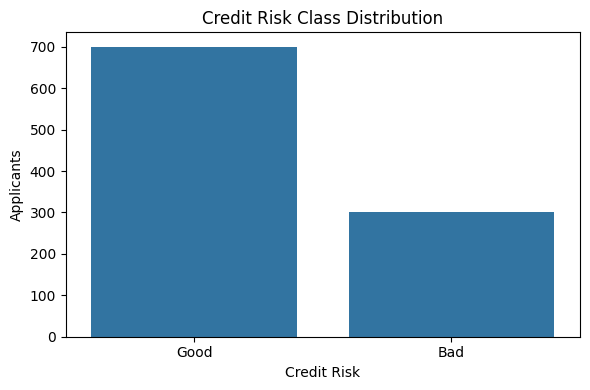

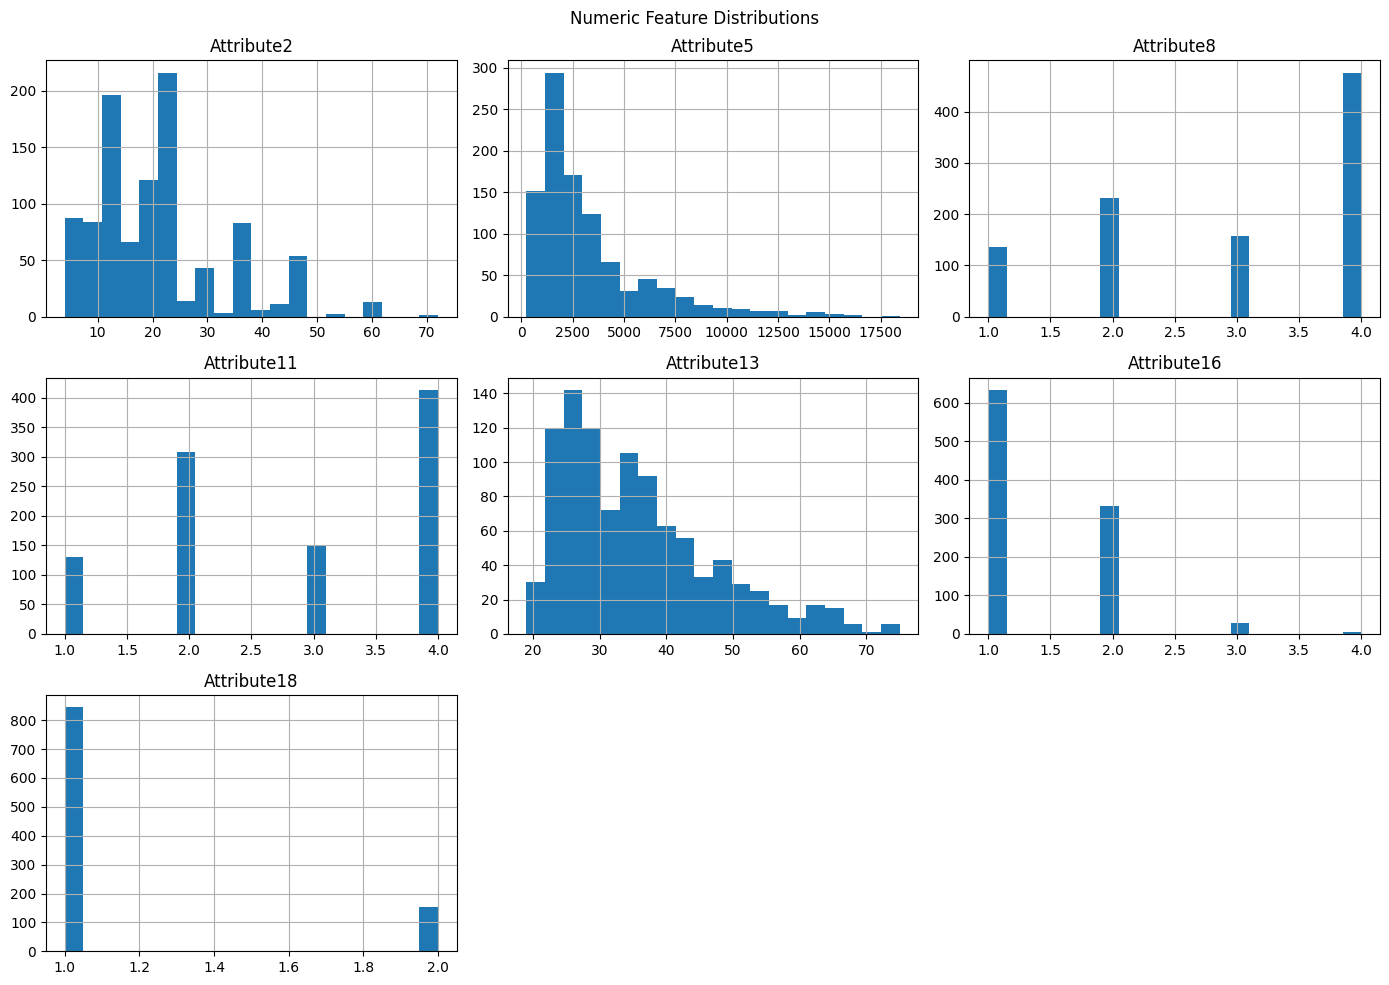

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x=y.map({1:'Good', 2:'Bad'}))
plt.title('Credit Risk Class Distribution')
plt.xlabel('Credit Risk')
plt.ylabel('Applicants')
plt.tight_layout()
plt.show()

numeric_cols_raw = X.select_dtypes(include=np.number).columns.tolist()
if numeric_cols_raw:
    X[numeric_cols_raw].hist(figsize=(14,10), bins=20)
    plt.suptitle('Numeric Feature Distributions')
    plt.tight_layout()
    plt.show()


# Diagnostic analytics
Diagnostic analytics asks why risk outcomes differ. Here we compare Good vs Bad applicants across numeric variables and inspect associations in the numeric portion of the data.

CreditRisk,Bad,Good
Attribute2,24.860000,19.207143
Attribute5,3938.126667,2985.457143
Attribute8,3.096667,2.920000
Attribute11,2.850000,2.842857
Attribute13,33.963333,36.224286
Attribute16,1.366667,1.424286
Attribute18,1.153333,1.155714


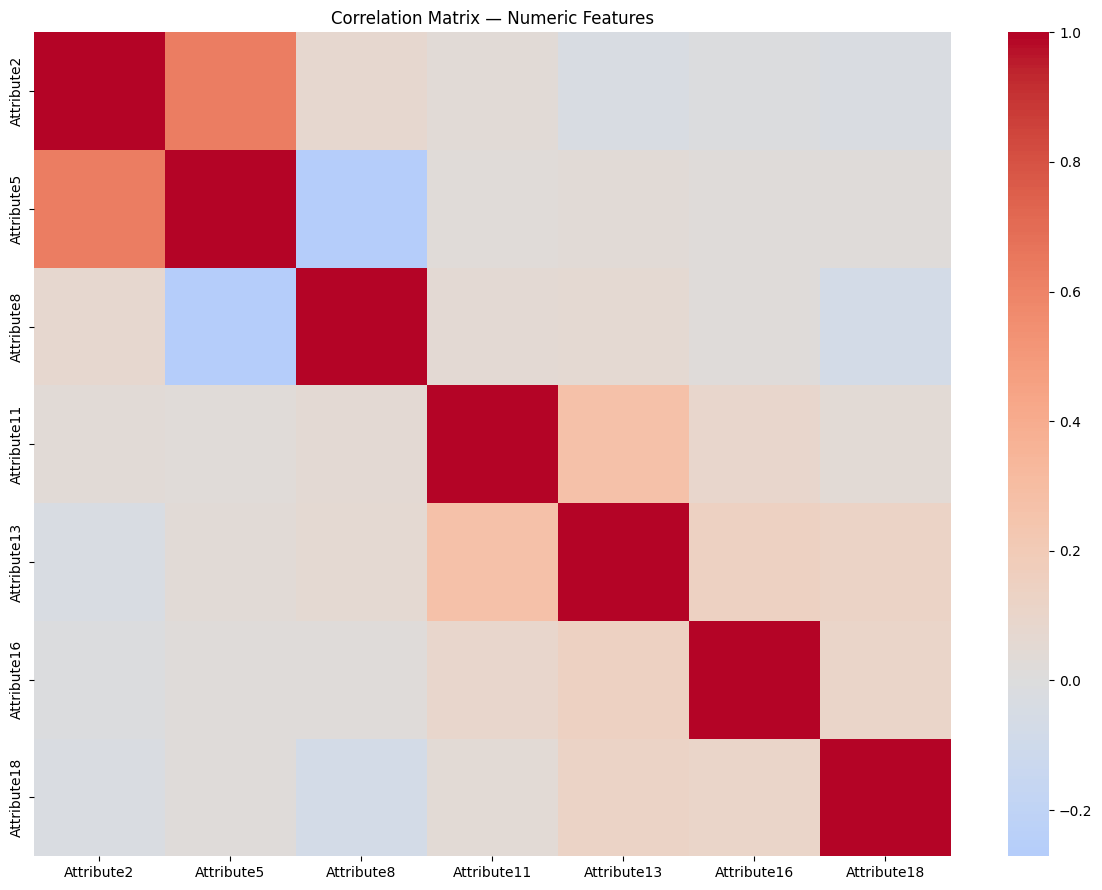

In [16]:
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
diagnostic = X.copy()
diagnostic['CreditRisk'] = y.map({1:'Good', 2:'Bad'})

if numeric_cols:
    group_stats = diagnostic.groupby('CreditRisk')[numeric_cols].mean().T
    display(group_stats)

    corr = diagnostic[numeric_cols].corr()
    plt.figure(figsize=(12,9))
    sns.heatmap(corr, cmap='coolwarm', center=0)
    plt.title('Correlation Matrix — Numeric Features')
    plt.tight_layout()
    plt.show()


## 4. Train/test split
A stratified split preserves the Good/Bad class proportions in both sets. The test set is kept untouched until final model comparison.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print('Train:', X_train.shape, 'Test:', X_test.shape)
print('\nTrain class distribution:')
print(y_train.value_counts(normalize=True).sort_index())


Train: (700, 20) Test: (300, 20)

Train class distribution:
class
1    0.7
2    0.3
Name: proportion, dtype: float64


## 5. Preprocessing pipeline
Categorical attributes are one-hot encoded and numeric attributes are standardized. Missing values are handled inside the pipeline to prevent data leakage.

In [18]:
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
])

base_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=3000, solver='liblinear', random_state=RANDOM_STATE))
])

param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__class_weight': [None, 'balanced']
}


# Predictive analytics
Two model-selection strategies are used on the training data:
1. **Accuracy model:** hyperparameters selected using accuracy.
2. **Recall model:** hyperparameters selected using recall for the Bad class.

The test set is used only after selection. This makes the final comparison more honest.

In [21]:

# Create a scorer specifically for the Bad class
bad_recall_scorer = make_scorer(
    recall_score,
    pos_label=BAD_CLASS
)

# Model optimized for accuracy
accuracy_search = GridSearchCV(
    base_pipeline,
    param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    refit=True
)

# Model optimized for Bad-class recall
recall_search = GridSearchCV(
    base_pipeline,
    param_grid,
    scoring=bad_recall_scorer,
    cv=5,
    n_jobs=-1,
    refit=True
)

# Train both searches
accuracy_search.fit(X_train, y_train)
recall_search.fit(X_train, y_train)

# Get the best models
accuracy_model = accuracy_search.best_estimator_
recall_model = recall_search.best_estimator_

# Display results
print('Accuracy-optimized parameters:', accuracy_search.best_params_)
print('Recall-optimized parameters:', recall_search.best_params_)

print('CV accuracy:', round(accuracy_search.best_score_, 4))
print('CV Bad-class recall:', round(recall_search.best_score_, 4))

Accuracy-optimized parameters: {'model__C': 0.1, 'model__class_weight': None}
Recall-optimized parameters: {'model__C': 0.01, 'model__class_weight': 'balanced'}
CV accuracy: 0.7386
CV Bad-class recall: 0.6952


In [22]:
def evaluate_model(name, model, X_eval, y_eval):
    pred = model.predict(X_eval)
    proba = model.predict_proba(X_eval)[:, list(model.classes_).index(BAD_CLASS)]
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_eval, pred),
        'Precision_Bad': precision_score(y_eval, pred, pos_label=BAD_CLASS, zero_division=0),
        'Recall_Bad': recall_score(y_eval, pred, pos_label=BAD_CLASS, zero_division=0),
        'F1_Bad': f1_score(y_eval, pred, pos_label=BAD_CLASS, zero_division=0),
        'ROC_AUC': roc_auc_score((y_eval == BAD_CLASS).astype(int), proba)
    }

results = pd.DataFrame([
    evaluate_model('Accuracy-optimized', accuracy_model, X_test, y_test),
    evaluate_model('Recall-optimized', recall_model, X_test, y_test)
])
display(results.round(4))

print('\nAccuracy-optimized report:')
print(classification_report(y_test, accuracy_model.predict(X_test), target_names=['Good','Bad'], zero_division=0))
print('\nRecall-optimized report:')
print(classification_report(y_test, recall_model.predict(X_test), target_names=['Good','Bad'], zero_division=0))


,Model,Accuracy,Precision_Bad,Recall_Bad,F1_Bad,ROC_AUC
0,Accuracy-optimized,0.7833,0.7193,0.4556,0.5578,0.8075
1,Recall-optimized,0.7100,0.5116,0.7333,0.6027,0.8067



Accuracy-optimized report:
              precision    recall  f1-score   support

        Good       0.80      0.92      0.86       210
         Bad       0.72      0.46      0.56        90

    accuracy                           0.78       300
   macro avg       0.76      0.69      0.71       300
weighted avg       0.77      0.78      0.77       300


Recall-optimized report:
              precision    recall  f1-score   support

        Good       0.86      0.70      0.77       210
         Bad       0.51      0.73      0.60        90

    accuracy                           0.71       300
   macro avg       0.69      0.72      0.69       300
weighted avg       0.76      0.71      0.72       300



## 6. Visualization of model performance


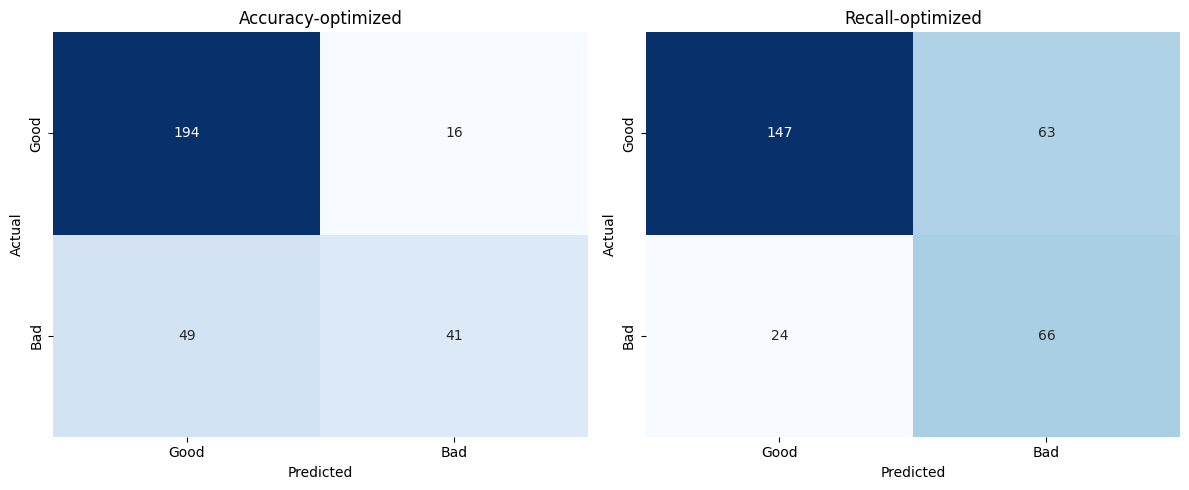

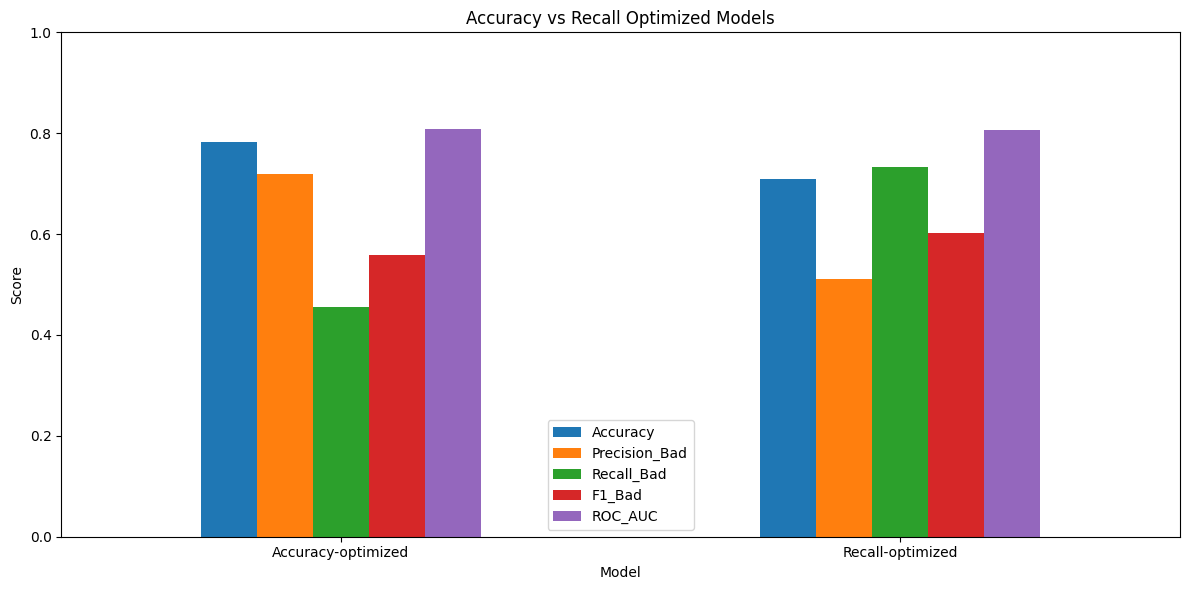

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
for ax, (name, model) in zip(axes, [('Accuracy-optimized', accuracy_model), ('Recall-optimized', recall_model)]):
    pred = model.predict(X_test)
    cm = confusion_matrix(y_test, pred, labels=[GOOD_CLASS, BAD_CLASS])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Good','Bad'], yticklabels=['Good','Bad'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

metrics_to_plot = ['Accuracy','Precision_Bad','Recall_Bad','F1_Bad','ROC_AUC']
plot_df = results.set_index('Model')[metrics_to_plot]
plot_df.plot(kind='bar', figsize=(12,6))
plt.ylim(0,1)
plt.title('Accuracy vs Recall Optimized Models')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# Business impact analysis
A credit-risk team is interested in the cost of **missed risky applicants**. Here, an applicant is a missed risky applicant when the true class is Bad but the model predicts Good (a false negative for the Bad class).

The business case below counts how many additional Bad applicants the recall-optimized model catches compared with the accuracy-optimized model, then multiplies that difference by the assumed average default loss.

In [24]:
def bad_false_negatives(model, X_eval, y_eval):
    pred = model.predict(X_eval)
    return int(((y_eval == BAD_CLASS) & (pred == GOOD_CLASS)).sum())

accuracy_fn = bad_false_negatives(accuracy_model, X_test, y_test)
recall_fn = bad_false_negatives(recall_model, X_test, y_test)

additional_bad_caught = accuracy_fn - recall_fn
estimated_avoided_loss = additional_bad_caught * AVERAGE_DEFAULT_LOSS

business_case = pd.DataFrame({
    'Measure': [
        'Bad applicants missed by accuracy model',
        'Bad applicants missed by recall model',
        'Additional Bad applicants caught by recall model',
        'Average default loss assumption',
        'Estimated avoided default loss'
    ],
    'Value': [accuracy_fn, recall_fn, additional_bad_caught,
              AVERAGE_DEFAULT_LOSS, estimated_avoided_loss]
})
display(business_case)

print(f'Accuracy model missed Bad applicants: {accuracy_fn}')
print(f'Recall model missed Bad applicants: {recall_fn}')
print(f'Additional Bad applicants caught by recall model: {additional_bad_caught}')
print(f'Estimated avoided loss: {estimated_avoided_loss:,.2f}')


,Measure,Value
0,Bad applicants missed by accuracy model,49.0
1,Bad applicants missed by recall model,24.0
2,Additional Bad applicants caught by recall model,25.0
3,Average default loss assumption,5000.0
4,Estimated avoided default loss,125000.0


Accuracy model missed Bad applicants: 49
Recall model missed Bad applicants: 24
Additional Bad applicants caught by recall model: 25
Estimated avoided loss: 125,000.00


## 7. UCI cost-matrix perspective
UCI documents this dataset's cost matrix as:
- Actual Good / Predicted Bad: cost 1
- Actual Bad / Predicted Good: cost 5

This means a missed Bad applicant is treated as five times as costly as incorrectly classifying a Good applicant as Bad in the supplied UCI cost matrix. The business default-loss calculation above is separate and should use the organization's own financial assumption.

In [25]:
UCI_COST_GOOD_AS_BAD = 1
UCI_COST_BAD_AS_GOOD = 5

def uci_cost(model, X_eval, y_eval):
    pred = model.predict(X_eval)
    actual_good_pred_bad = ((y_eval == GOOD_CLASS) & (pred == BAD_CLASS)).sum()
    actual_bad_pred_good = ((y_eval == BAD_CLASS) & (pred == GOOD_CLASS)).sum()
    return (actual_good_pred_bad * UCI_COST_GOOD_AS_BAD +
            actual_bad_pred_good * UCI_COST_BAD_AS_GOOD)

print('UCI-style cost — accuracy model:', uci_cost(accuracy_model, X_test, y_test))
print('UCI-style cost — recall model:', uci_cost(recall_model, X_test, y_test))


UCI-style cost — accuracy model: 261
UCI-style cost — recall model: 183


# Final interpretation
- Accuracy answers: **How often was the overall classification correct?**
- Bad-class recall answers: **Of the genuinely risky applicants, how many did we identify?**
- In lending, the preferred metric depends on the organization's documented cost of false positives versus false negatives.
- This notebook does not assume that one metric is universally correct; it demonstrates the business impact of choosing the metric that matches the error cost.

## Limitations
1. The dataset is small (1,000 records) and historical.
2. Model performance can vary with the train/test split; cross-validation is therefore used for model selection.
3. The average default loss is a configurable business assumption.
4. This notebook is a teaching/business-practice example, not a production lending-decision system.
5. Fair-lending, regulatory, explainability, calibration, monitoring, and human-review requirements would need to be addressed before deployment.
